# 第 2 章：線性組合、生成空間與線性獨立

本 Notebook 是 [`ch02_span_independence.md`](./ch02_span_independence.md) 的精簡對照版，
程式碼與 [`ch02_span_independence.py`](./ch02_span_independence.py) 邏輯一致。

## 學習目標

- 理解線性組合、生成空間 (span) 的定義與幾何意義
- 分辨線性獨立與線性相依
- 用「解齊次方程組」與「矩陣的秩 (rank)」兩種方法判斷線性獨立
- 建立秩 (rank) 的直觀意義（完整理論在第 7 章）


In [1]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

plt.rcParams["font.sans-serif"] = [
    "PingFang TC", "Heiti TC", "Arial Unicode MS", "Microsoft JhengHei", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

OUT_DIR = os.getcwd()
print("目前工作目錄:", OUT_DIR)


目前工作目錄: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch02_span_independence


## 1. 線性組合 (Linear Combination)

$$
c_1 v_1 + c_2 v_2 + \cdots + c_n v_n
$$

**手算範例**：$v_1=\begin{bmatrix}1\\0\end{bmatrix}$、$v_2=\begin{bmatrix}0\\1\end{bmatrix}$，
目標 $b=\begin{bmatrix}5\\-1\end{bmatrix}$，解 $c_1 v_1 + c_2 v_2 = b$ 得 $c_1=5,\ c_2=-1$。


In [2]:
v1 = np.array([1, 0])
v2 = np.array([0, 1])
c1, c2 = 3, -2

combo = c1 * v1 + c2 * v2
print(f"v1 = {v1}, v2 = {v2}")
print(f"c1 = {c1}, c2 = {c2}")
print(f"線性組合 c1*v1 + c2*v2 = {combo}")

# 判斷目標向量 b 是否可以用 v1, v2 的線性組合表示：解 A c = b
b = np.array([5, -1])
A = np.column_stack([v1, v2])
coeffs, *_ = np.linalg.lstsq(A, b, rcond=None)
residual = A @ coeffs - b
print(f"\n目標向量 b = {b}")
print(f"解出的係數 (c1, c2) = {coeffs}")
print(f"驗證 A @ coeffs - b = {residual} (應接近 0 向量，代表 b 確實在 span{{v1, v2}} 中)")


v1 = [1 0], v2 = [0 1]
c1 = 3, c2 = -2
線性組合 c1*v1 + c2*v2 = [ 3 -2]

目標向量 b = [ 5 -1]
解出的係數 (c1, c2) = [ 5. -1.]
驗證 A @ coeffs - b = [0. 0.] (應接近 0 向量，代表 b 確實在 span{v1, v2} 中)


## 2. 生成空間 (Span) 的幾何意義

兩個**不平行**的 2D 向量可以生成 (span) 整個平面 $\mathbb{R}^2$。下面用大量隨機係數
$(c_1, c_2)$ 產生線性組合，畫出散佈圖直觀呈現這個事實。


v1 = [2 1], v2 = [-1  1] 彼此不平行，兩者可以生成 (span) 整個 2D 平面 R^2。


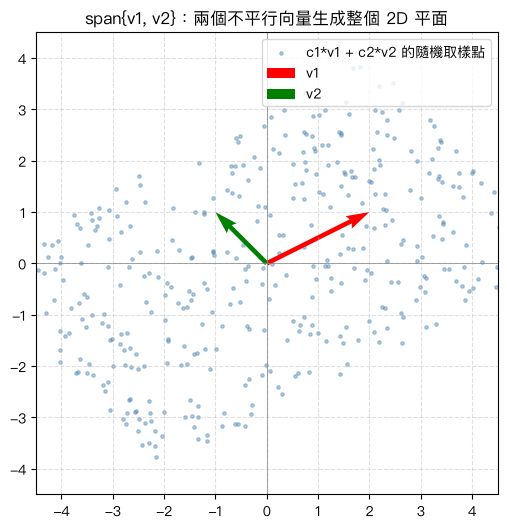

圖片已存至: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch02_span_independence/span_demo.png


In [3]:
v1 = np.array([2, 1])
v2 = np.array([-1, 1])
print(f"v1 = {v1}, v2 = {v2} 彼此不平行，兩者可以生成 (span) 整個 2D 平面 R^2。")

rng = np.random.default_rng(42)
coeffs = rng.uniform(-2, 2, size=(400, 2))
points = coeffs @ np.array([v1, v2])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=6, alpha=0.4, color="steelblue",
           label="c1*v1 + c2*v2 的隨機取樣點")
ax.quiver(0, 0, v1[0], v1[1], angles="xy", scale_units="xy", scale=1,
          color="red", width=0.01, label="v1")
ax.quiver(0, 0, v2[0], v2[1], angles="xy", scale_units="xy", scale=1,
          color="green", width=0.01, label="v2")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect("equal")
ax.set_title("span{v1, v2}：兩個不平行向量生成整個 2D 平面")
ax.legend(loc="upper right")
ax.grid(True, linestyle="--", alpha=0.4)

out_path = os.path.join(OUT_DIR, "span_demo.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"圖片已存至: {out_path}")


## 3. 線性獨立 / 線性相依的判斷

**定義**：$c_1 v_1 + \cdots + c_n v_n = \mathbf{0}$ 只有零解 $\Leftrightarrow$ 線性獨立；
存在非零解 $\Leftrightarrow$ 線性相依。

下面手刻一個函式，用高斯消去法（部分主元法）化簡列梯形式，數主元個數是否等於向量個數，
藉此判斷線性獨立性；再用 `np.linalg.matrix_rank` 做交叉驗證。


In [4]:
def is_independent_by_homogeneous_system(vectors: list[np.ndarray], tol: float = 1e-10) -> bool:
    """
    手刻函式：判斷一組向量是否線性獨立。
    做法：把向量當作矩陣 A 的欄向量，用高斯消去法化簡為列梯形式，
    數主元 (pivot) 個數是否等於向量個數，藉此判斷 A c = 0 是否只有零解。
    """
    A = np.column_stack(vectors).astype(float)
    n_rows, n_cols = A.shape

    M = A.copy()
    pivot_row = 0
    pivot_cols = []
    for col in range(n_cols):
        if pivot_row >= n_rows:
            break
        max_row = pivot_row + np.argmax(np.abs(M[pivot_row:, col]))
        if np.abs(M[max_row, col]) < tol:
            continue
        M[[pivot_row, max_row]] = M[[max_row, pivot_row]]
        for r in range(pivot_row + 1, n_rows):
            factor = M[r, col] / M[pivot_row, col]
            M[r, :] -= factor * M[pivot_row, :]
        pivot_cols.append(col)
        pivot_row += 1

    return len(pivot_cols) == n_cols


In [5]:
# 範例 A：兩個不平行的 2D 向量 -> 線性獨立
v1 = np.array([1, 2])
v2 = np.array([3, 1])
vectors_a = [v1, v2]
A = np.column_stack(vectors_a)
print(f"範例 A: v1 = {v1}, v2 = {v2}")
print(f"  手刻函式判斷 (解齊次方程組是否只有零解): "
      f"{'線性獨立' if is_independent_by_homogeneous_system(vectors_a) else '線性相依'}")
print(f"  matrix_rank(A) = {np.linalg.matrix_rank(A)}, 向量個數 = {len(vectors_a)} "
      f"-> {'線性獨立' if np.linalg.matrix_rank(A) == len(vectors_a) else '線性相依'}")


範例 A: v1 = [1 2], v2 = [3 1]
  手刻函式判斷 (解齊次方程組是否只有零解): 線性獨立
  matrix_rank(A) = 2, 向量個數 = 2 -> 線性獨立


In [6]:
# 範例 B：三個 2D 向量，其中 v3 = v1 + 2*v2 -> 必定線性相依
v1b = np.array([1, 0])
v2b = np.array([0, 1])
v3b = v1b + 2 * v2b
vectors_b = [v1b, v2b, v3b]
B = np.column_stack(vectors_b)
print(f"範例 B: v1 = {v1b}, v2 = {v2b}, v3 = v1 + 2*v2 = {v3b}")
print(f"  手刻函式判斷: "
      f"{'線性獨立' if is_independent_by_homogeneous_system(vectors_b) else '線性相依'}")
print(f"  matrix_rank(B) = {np.linalg.matrix_rank(B)}, 向量個數 = {len(vectors_b)} "
      f"-> {'線性獨立' if np.linalg.matrix_rank(B) == len(vectors_b) else '線性相依'}")
print("  說明：因為 v3 = 1*v1 + 2*v2，所以 1*v1 + 2*v2 + (-1)*v3 = 0 是一組非零解，"
      "代表這三個向量線性相依。")


範例 B: v1 = [1 0], v2 = [0 1], v3 = v1 + 2*v2 = [1 2]
  手刻函式判斷: 線性相依
  matrix_rank(B) = 2, 向量個數 = 3 -> 線性相依
  說明：因為 v3 = 1*v1 + 2*v2，所以 1*v1 + 2*v2 + (-1)*v3 = 0 是一組非零解，代表這三個向量線性相依。


In [7]:
# 範例 C：3D 空間中三個線性獨立的向量（標準基底）
v1c = np.array([1, 0, 0])
v2c = np.array([0, 1, 0])
v3c = np.array([0, 0, 1])
vectors_c = [v1c, v2c, v3c]
C = np.column_stack(vectors_c)
print(f"範例 C (3D 標準基底): v1 = {v1c}, v2 = {v2c}, v3 = {v3c}")
print(f"  matrix_rank(C) = {np.linalg.matrix_rank(C)}, 向量個數 = {len(vectors_c)} "
      f"-> {'線性獨立' if np.linalg.matrix_rank(C) == len(vectors_c) else '線性相依'}")


範例 C (3D 標準基底): v1 = [1 0 0], v2 = [0 1 0], v3 = [0 0 1]
  matrix_rank(C) = 3, 向量個數 = 3 -> 線性獨立


## 4. 秩 (Rank) 的直觀意義

秩代表一組向量「實際能撐出的空間維度」。第 7 章會更完整地討論向量空間、行空間、零空間與
秩-零度定理，這裡先建立直觀概念：秩 = 向量個數 $\Rightarrow$ 線性獨立；秩 < 向量個數 $\Rightarrow$ 線性相依。


In [8]:
examples = {
    "滿秩方陣 (2x2 獨立)": np.array([[1, 3], [2, 1]]),
    "秩為 1 的方陣 (兩列成比例)": np.array([[1, 2], [2, 4]]),
    "3 個向量在 2D 空間 (最多秩 2)": np.array([[1, 0, 1], [0, 1, 2]]),
}
for name, M in examples.items():
    r = np.linalg.matrix_rank(M)
    print(f"{name}:\n{M}\n  matrix_rank = {r}  (矩陣形狀 {M.shape})\n")


滿秩方陣 (2x2 獨立):
[[1 3]
 [2 1]]
  matrix_rank = 2  (矩陣形狀 (2, 2))

秩為 1 的方陣 (兩列成比例):
[[1 2]
 [2 4]]
  matrix_rank = 1  (矩陣形狀 (2, 2))

3 個向量在 2D 空間 (最多秩 2):
[[1 0 1]
 [0 1 2]]
  matrix_rank = 2  (矩陣形狀 (2, 3))



## 5. 幾何直觀圖示：三個線性相依向量

取 $v_1=\begin{bmatrix}2\\1\end{bmatrix}$、$v_2=\begin{bmatrix}-1\\1\end{bmatrix}$、
$v_3=v_1+v_2$，三者共平面、線性相依，$v_3$ 沒有提供新的方向。


v1 = [2 1], v2 = [-1  1], v3 = v1 + v2 = [1 2]
三者線性相依（v1*1 + v2*1 + v3*(-1) = 0 是非零解）。


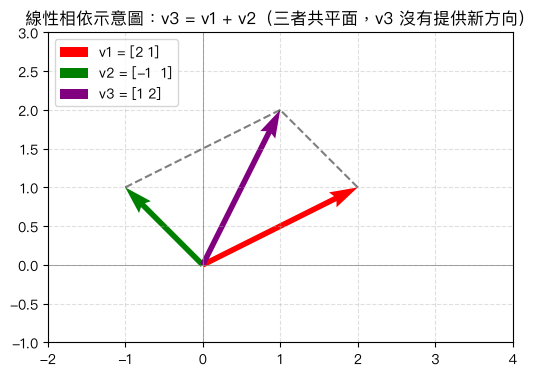

圖片已存至: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch02_span_independence/dependent_vectors_demo.png


In [9]:
v1 = np.array([2, 1])
v2 = np.array([-1, 1])
v3 = v1 + v2  # v3 是 v1, v2 的線性組合
print(f"v1 = {v1}, v2 = {v2}, v3 = v1 + v2 = {v3}")
print("三者線性相依（v1*1 + v2*1 + v3*(-1) = 0 是非零解）。")

fig, ax = plt.subplots(figsize=(6, 6))
origin = np.array([0, 0])
colors = {"v1": "red", "v2": "green", "v3": "purple"}
for name, v in zip(["v1", "v2", "v3"], [v1, v2, v3]):
    ax.quiver(*origin, v[0], v[1], angles="xy", scale_units="xy", scale=1,
               color=colors[name], width=0.012, label=f"{name} = {v}")

ax.plot([v1[0], v3[0]], [v1[1], v3[1]], "k--", alpha=0.5)
ax.plot([v2[0], v3[0]], [v2[1], v3[1]], "k--", alpha=0.5)

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-2, 4)
ax.set_ylim(-1, 3)
ax.set_aspect("equal")
ax.set_title("線性相依示意圖：v3 = v1 + v2（三者共平面，v3 沒有提供新方向）")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)

out_path = os.path.join(OUT_DIR, "dependent_vectors_demo.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"圖片已存至: {out_path}")


## 重點整理

- **線性組合**：$c_1 v_1 + c_2 v_2 + \cdots + c_n v_n$
- **生成空間 (span)**：一組向量所有線性組合的集合；兩個不平行的 2D 向量可 span 整個平面
- **線性獨立**：齊次方程組只有零解；**線性相依**：存在非零解
- **判斷方法**：解齊次方程組 或 比較矩陣的秩與向量個數
- **秩**：一組向量實際撐出的空間維度，完整理論見第 7 章

更完整的手算範例、MATLAB 對照程式碼與練習題，請參閱
[`ch02_span_independence.md`](./ch02_span_independence.md)。
